In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

In [6]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [8]:
df.shape

(15509, 10)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [16]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [18]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [20]:
df = df.dropna(subset=['Rating'])

In [23]:
df.shape

(7919, 10)

In [25]:
df['Genre'] = df['Genre'].fillna(df['Genre'].mode()[0])
df['Director'] = df['Director'].fillna(df['Director'].mode()[0])
df['Actor 1'] = df['Actor 1'].fillna(df['Actor 1'].mode()[0])
df['Actor 2'] = df['Actor 2'].fillna(df['Actor 2'].mode()[0])
df['Actor 3'] = df['Actor 3'].fillna(df['Actor 3'].mode()[0])

In [31]:
df['Genre'] = df['Genre'].fillna(df['Genre'].mode()[0])
df['Director'] = df['Director'].fillna(df['Director'].mode()[0])
df['Actor 1'] = df['Actor 1'].fillna(df['Actor 1'].mode()[0])
df['Actor 2'] = df['Actor 2'].fillna(df['Actor 2'].mode()[0])
df['Actor 3'] = df['Actor 3'].fillna(df['Actor 3'].mode()[0])

In [33]:
df.isnull().sum()

Name           0
Year           0
Duration    2068
Genre          0
Rating         0
Votes          0
Director       0
Actor 1        0
Actor 2        0
Actor 3        0
dtype: int64

In [37]:
df['Duration'].dtype

dtype('float64')

In [39]:
df['Duration'] = df['Duration'].fillna(df['Duration'].median())

In [41]:
df['Duration'] = df['Duration'].astype(str).str.replace(' min', '', regex=False)
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
df['Duration'] = df['Duration'].fillna(df['Duration'].median())

In [43]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),109.0,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,(2019),110.0,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,(1997),147.0,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142.0,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,(2012),82.0,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [45]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['Name', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [47]:
df.dtypes

Name          int64
Year         object
Duration    float64
Genre         int64
Rating      float64
Votes        object
Director      int64
Actor 1       int64
Actor 2       int64
Actor 3       int64
dtype: object

In [50]:
df['Year'].dtype

dtype('int64')

In [53]:
X = df.drop('Rating', axis=1)
y = df['Rating']

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [57]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [59]:
y_pred = model.predict(X_test)

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE : 0.8355757575757575
RMSE: 1.1056031519245295
R2 Score: 0.3425159215256336


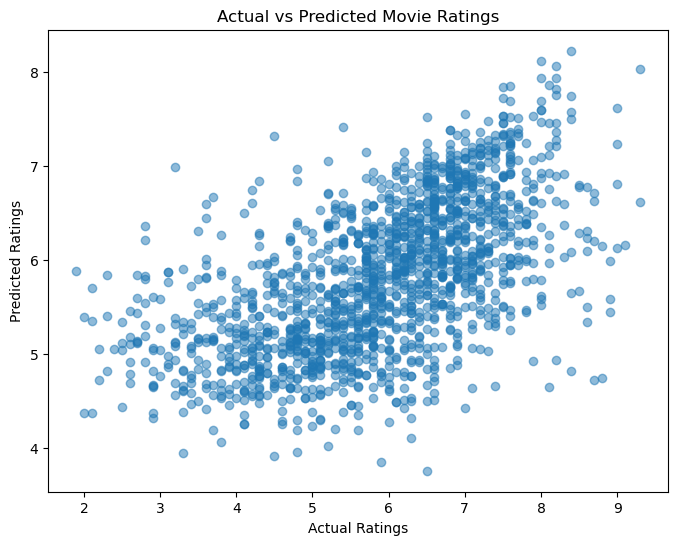

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Movie Ratings")
plt.show()

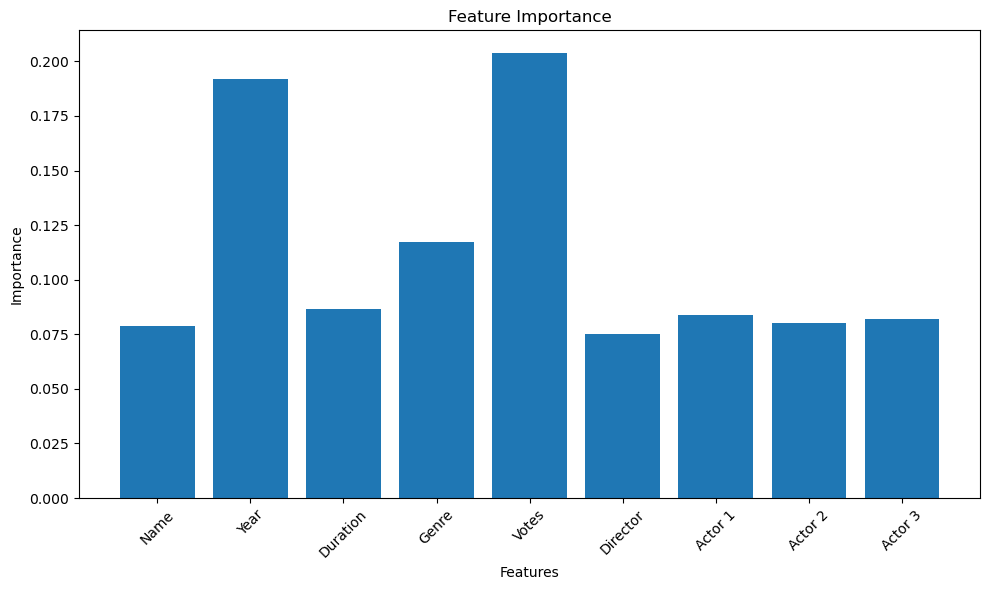

In [64]:
feature_importance = model.feature_importances_

plt.figure(figsize=(10,6))
plt.bar(X.columns, feature_importance)
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

# Movie Rating Prediction with Python

## Objective
The objective of this project is to predict movie ratings using machine learning based on features such as movie name, year, duration, genre, votes, director, and actors.

In [66]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [68]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (15509, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [70]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

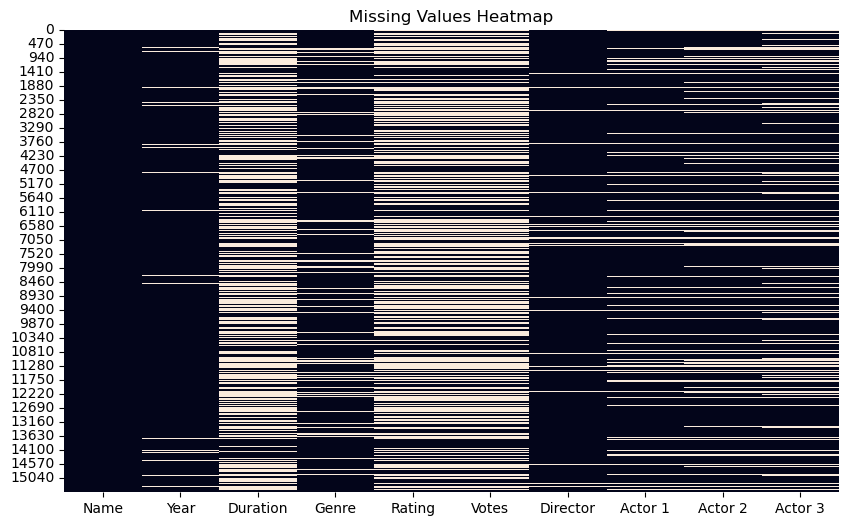

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

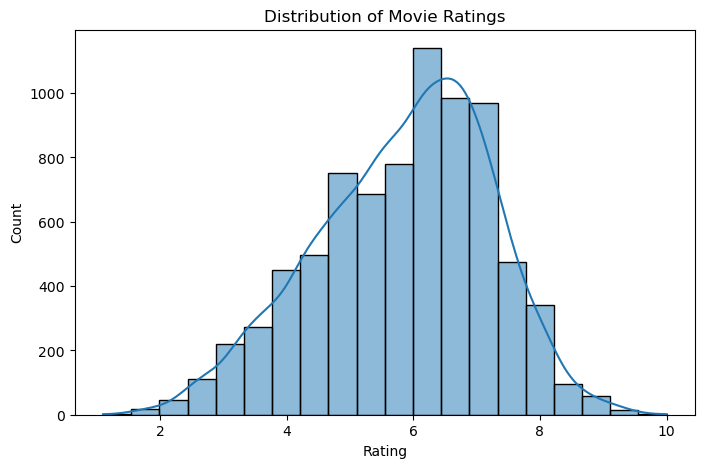

In [75]:
plt.figure(figsize=(8,5))
sns.histplot(df["Rating"], bins=20, kde=True)
plt.title("Distribution of Movie Ratings")
plt.show()

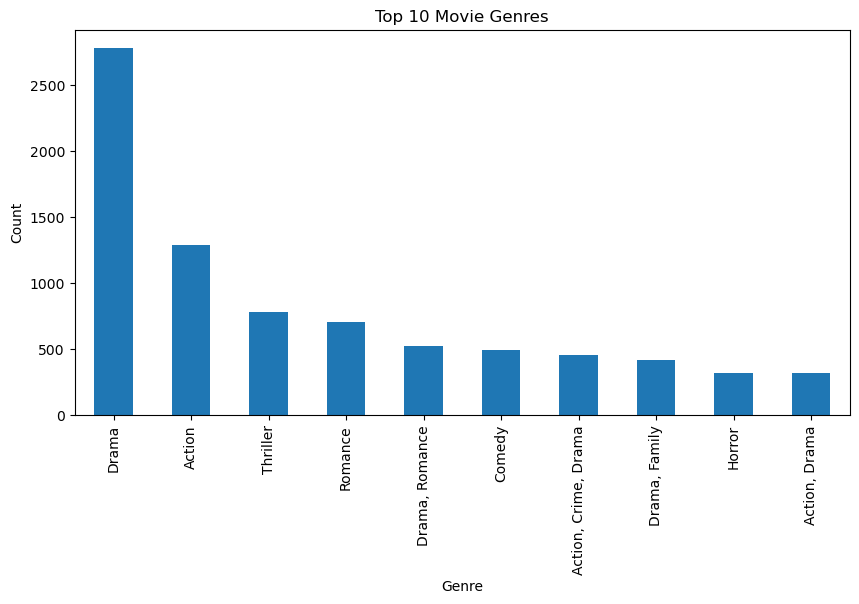

In [76]:
top_genres = df["Genre"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_genres.plot(kind="bar")
plt.title("Top 10 Movie Genres")
plt.ylabel("Count")
plt.show()

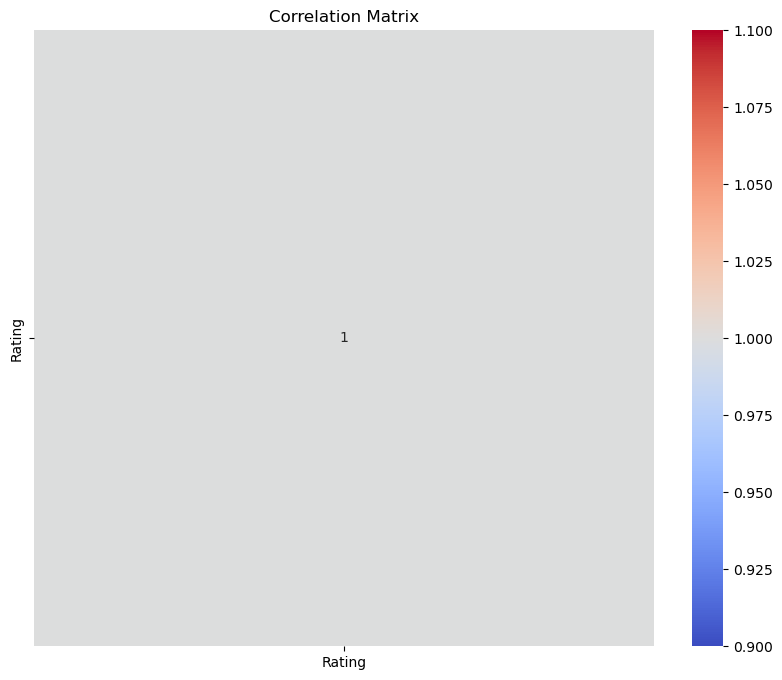

In [78]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [80]:
X = df.drop("Rating", axis=1)
y = df["Rating"]

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [83]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Dastak'

In [84]:
print(type(y))
print(y.shape)

<class 'pandas.core.series.Series'>
(15509,)


In [85]:
y.head()

0    NaN
1    7.0
2    NaN
3    4.4
4    NaN
Name: Rating, dtype: float64

In [86]:
X = df.drop(columns=['Rating'])
y = df['Rating']      # <-- single square brackets only

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [89]:
print(X_train.shape)
print(y_train.shape)

(12407, 9)
(12407,)


In [90]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Dastak'

In [92]:
print(X.dtypes)

Name        object
Year        object
Duration    object
Genre       object
Votes       object
Director    object
Actor 1     object
Actor 2     object
Actor 3     object
dtype: object


In [94]:
print(X.isnull().sum())

Name           0
Year         528
Duration    8269
Genre       1877
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [98]:
X = df.drop('Rating', axis=1)
y = df['Rating']

In [99]:
X.dtypes

Name        object
Year        object
Duration    object
Genre       object
Votes       object
Director    object
Actor 1     object
Actor 2     object
Actor 3     object
dtype: object

In [101]:
X.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64